# Exercício 1 - Matplotlib

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
df = pd.read_csv("../datasets/classification_results_trial_0001.csv")

In [9]:
df

,image_path,real_class,predicted_class,prob_benign,prob_malign
0,image_001.jpg,malign,malign,0.031429,0.968571
1,image_002.jpg,benign,benign,0.636410,0.363590
2,image_003.jpg,malign,malign,0.314356,0.685644
3,image_004.jpg,benign,benign,0.508571,0.491429
4,image_005.jpg,benign,benign,0.907566,0.092434
...,...,...,...,...,...
95,image_096.jpg,malign,malign,0.349210,0.650790
96,image_097.jpg,benign,benign,0.725956,0.274044
97,image_098.jpg,benign,benign,0.897110,0.102890
98,image_099.jpg,benign,benign,0.887086,0.112914


## Gráfico de barras: contagem por real_class.

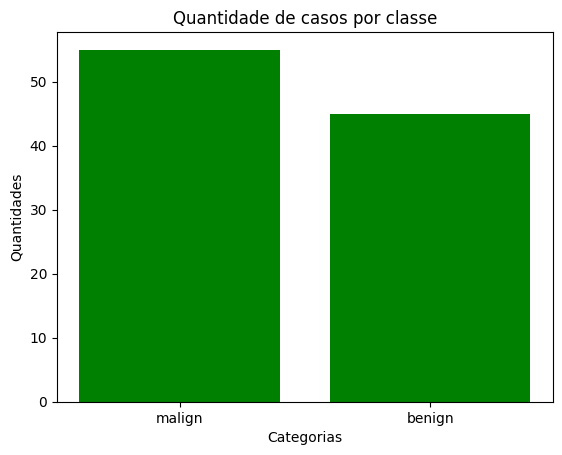

In [ ]:
categorias = df["real_class"].value_counts()

plt.bar(categorias.index, categorias.values, color="g")

plt.xlabel('Categorias')
plt.ylabel('Quantidades')
plt.title('Quantidade de casos por classe')

plt.show()

## Gráfico de barras: contagem por predicted_class.

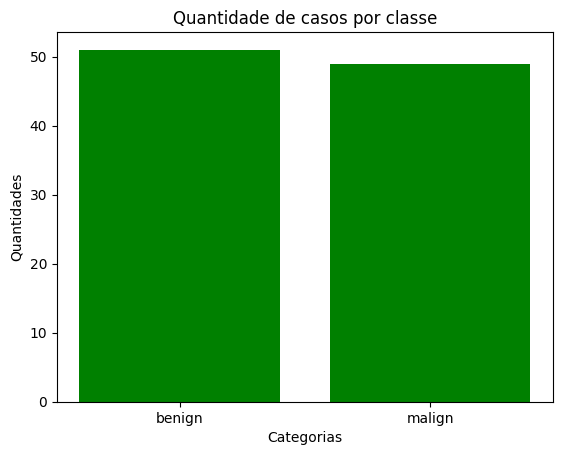

In [19]:
categorias = df["predicted_class"].value_counts()

plt.bar(categorias.index, categorias.values, color="g")

plt.xlabel('Categorias')
plt.ylabel('Quantidades')
plt.title('Quantidade de casos por classe')

plt.show()

### Histograma de prob_benign

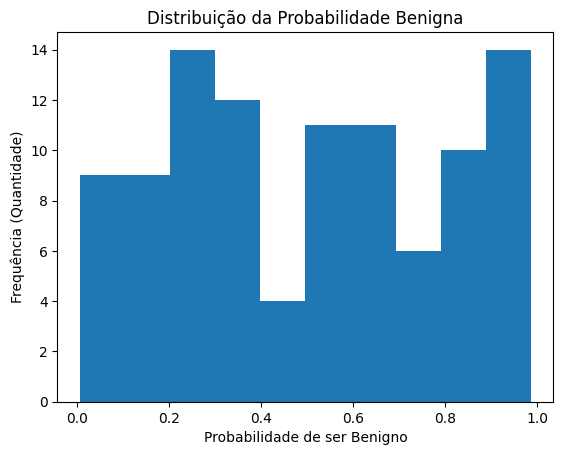

In [23]:
data = df["prob_benign"]

plt.hist(data)

plt.xlabel('Probabilidade de ser Benigno')
plt.ylabel('Frequência (Quantidade)')
plt.title('Distribuição da Probabilidade Benigna')

plt.show()

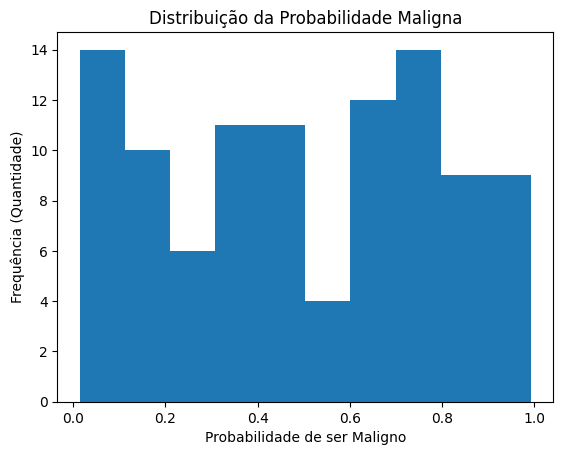

In [25]:
data = df["prob_malign"]

plt.hist(data)

plt.xlabel('Probabilidade de ser Maligno')
plt.ylabel('Frequência (Quantidade)')
plt.title('Distribuição da Probabilidade Maligna')

plt.show()

### Scatter plot: X=prob_benign, Y=prob_malign, com cor diferente para acerto vs erro.

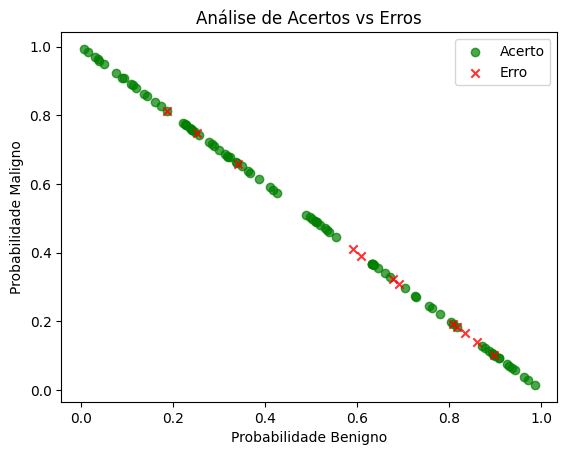

In [32]:
acertos = df[df['real_class'] == df['predicted_class']]
erros = df[df['real_class'] != df['predicted_class']]

plt.scatter(acertos['prob_benign'], acertos['prob_malign'], color='green', label='Acerto', alpha=0.7)

plt.scatter(erros['prob_benign'], erros['prob_malign'], color='red', label='Erro', alpha=0.8, marker='x')

plt.xlabel('Probabilidade Benigno')
plt.ylabel('Probabilidade Maligno')
plt.title('Análise de Acertos vs Erros')

plt.legend()

plt.show()

## Qual erro é mais comum (FP ou FN)? Crie um gráfico que ajude a visualizar isso.

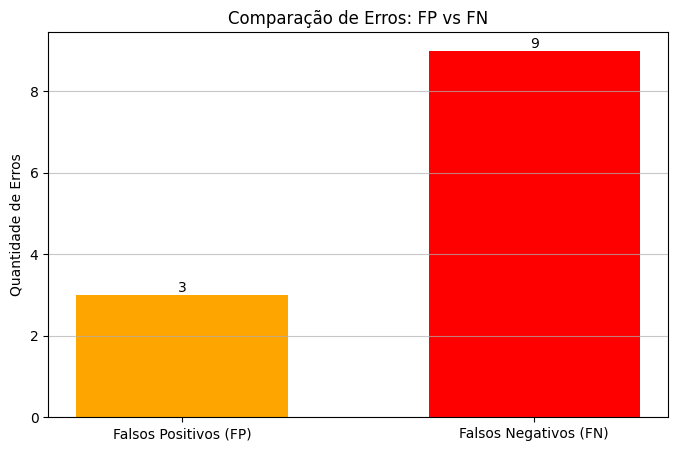

In [37]:
malign_df = df[df['real_class'] == 'malign']
benign_df = df[df['real_class'] == 'benign']

FP = (benign_df["real_class"] != benign_df['predicted_class']).sum()

FN = (malign_df["real_class"] != malign_df['predicted_class']).sum()

tipos_erro = ['Falsos Positivos (FP)', 'Falsos Negativos (FN)']

plt.figure(figsize=(8, 5))
barras = plt.bar(tipos_erro, [FP, FN], color=['orange', 'red'], width=0.6)

plt.bar_label(barras)

plt.ylabel('Quantidade de Erros')
plt.title('Comparação de Erros: FP vs FN')
plt.grid(axis='y', alpha=0.7)

plt.show()

## E em contexto médico: qual é mais preocupante e por quê?

O mais grave é o falso positivo, pois o paciente acredita que não tem nenhum problema e isso prejudica agir rapidamente na cura ou tratamento do mesmo, então é um atraso em seu tratamento.